Cargar dataset limpio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/titanic.csv")

df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_model = df_clean.drop(columns=["Cabin"])

df_model.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [2]:
df_model[df_model["Sex"] == "female"].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [4]:
df_model[(df_model["Sex"] == "male") & (df_model["Pclass"] == 3)].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,S


In [5]:
df_model[df_model["Survived"] == 1].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [6]:
df_model[df_model["Age"] > 60].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,Q
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,S


In [7]:
print("Cantidad de mujeres:", len(df_model[df_model["Sex"] == "female"]))

Cantidad de mujeres: 314


In [8]:
print("Pasajeros de tercera clase que sobrevivieron:", len(df_model[(df_model["Pclass"] == 3) & (df_model["Survived"] == 1)]))

Pasajeros de tercera clase que sobrevivieron: 119


In [9]:
print("Mayores de 60 que sobrevivieron:", len(df_model[(df_model["Age"] > 60) & (df_model["Survived"] == 1)]))

Mayores de 60 que sobrevivieron: 5


In [10]:
print(df_model.groupby("Sex")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [11]:
print(df_model.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [12]:
print(df_model.groupby("Sex")["Age"].mean())

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64


In [13]:
print(df_model.groupby("Pclass")["Fare"].mean())

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [14]:
print(df_model.groupby(["Sex", "Pclass"])["Survived"].mean())

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


In [15]:
df_model.sort_values("Fare", ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,C
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,C


In [16]:
df_model.sort_values("Age", ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,C
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,Q
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,S
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,C


In [17]:
fare_por_clase = df_model.groupby("Pclass")["Fare"].mean().reset_index()
fare_por_clase.sort_values("Fare", ascending=False)

,Pclass,Fare
0,1,84.154687
1,2,20.662183
2,3,13.675550


In [18]:
df_model["grupo_edad"] = pd.cut(
    df_model["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Niño", "Adolescente", "Joven Adulto", "Adulto", "Adulto Mayor"]
)

df_model[["Age", "grupo_edad"]].head(10)

,Age,grupo_edad
0,22.0,Joven Adulto
1,38.0,Adulto
2,26.0,Joven Adulto
3,35.0,Joven Adulto
4,35.0,Joven Adulto
5,28.0,Joven Adulto
6,54.0,Adulto
7,2.0,Niño
8,27.0,Joven Adulto
9,14.0,Adolescente


In [19]:
print(df_model.groupby("grupo_edad")["Survived"].mean())

grupo_edad
Niño            0.579710
Adolescente     0.428571
Joven Adulto    0.353271
Adulto          0.400000
Adulto Mayor    0.227273
Name: Survived, dtype: float64


/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/1516048450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby("grupo_edad")["Survived"].mean())


In [21]:
df_model["tamano_familia"] = df_model["SibSp"] + df_model["Parch"] + 1
df_model[["SibSp", "Parch", "tamano_familia"]].head()

,SibSp,Parch,tamano_familia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [22]:
print(df_model.groupby("tamano_familia")["Survived"].mean().head(10))

tamano_familia
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


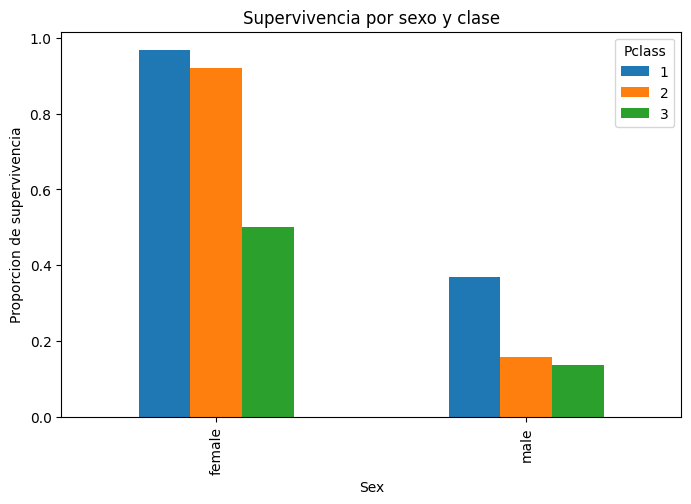

In [23]:
df_model.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().plot(kind="bar", figsize=(8,5))
plt.title("Supervivencia por sexo y clase")
plt.ylabel("Proporcion de supervivencia")
plt.show()

/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/3734186080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby("grupo_edad")["Survived"].mean().plot(kind="bar", figsize=(8,5))


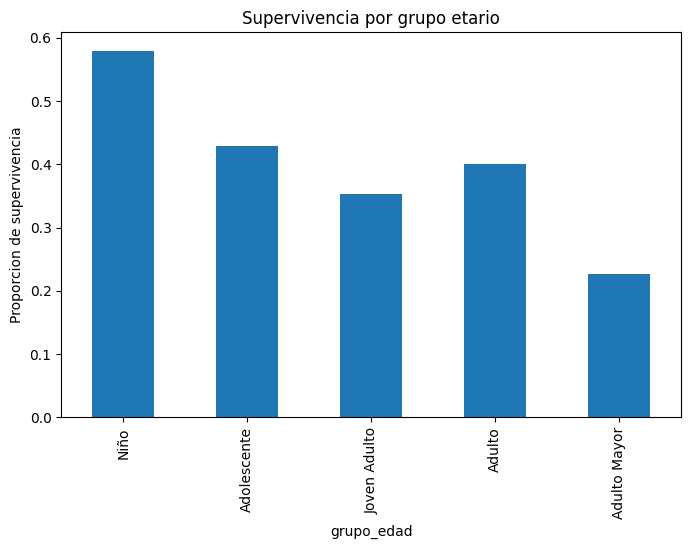

In [24]:
df_model.groupby("grupo_edad")["Survived"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Supervivencia por grupo etario")
plt.ylabel("Proporcion de supervivencia")
plt.show()

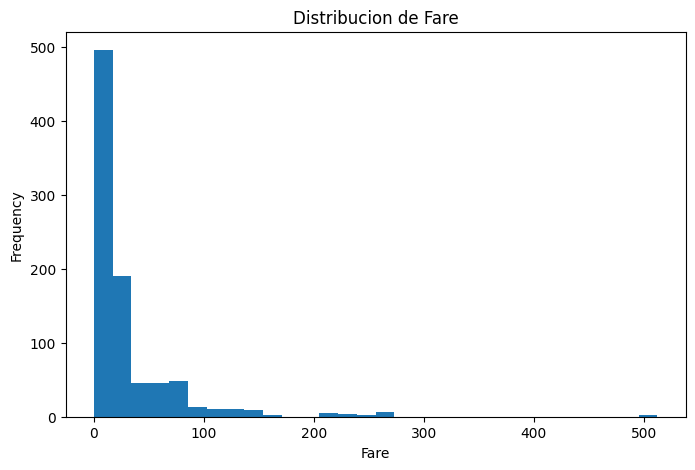

In [25]:
df_model["Fare"].plot(kind="hist", bins=30, figsize=(8,5))
plt.title("Distribucion de Fare")
plt.xlabel("Fare")
plt.show()

Quiero que hoy dejes respondidas estas preguntas dentro del notebook:

¿Qué grupo tuvo mayor tasa de supervivencia?
R: 
-Los niños tuvieron una mayor tasa de supervivecia dentro de los grupos por edad.
-Las mujeres tambièn fue un grupo que tuvo mayor supervivencia y esto explica que las mujeres y niños siempre prevalecen por sobre los hombres en general al momento de decidir elegir a quien salvar.
¿Influyó más el sexo o la clase?
R: Influye más el sexo que la clase
¿Los pasajeros con tarifas más altas tendieron a sobrevivir más?
Si, los pasajeros de tarifas más altas sobrevieron más.
¿El tamaño de la familia parece influir?
Influye hasta cierto punto, para las familias de 4 personas la probabilidad de sobrevivir es más alta, pero a medida que el grupo va creciendo la probabilidad de sobrevivir es menor. Se entiende que puede se que las familias prefiren mantenerse unidos hasta el final.
¿Qué grupo etario parece más favorecido?
Los niños son los más favorecidos, seguidos de los adolescentes.

In [27]:
survival_table = df_model.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()
survival_table

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


<Figure size 1000x600 with 0 Axes>

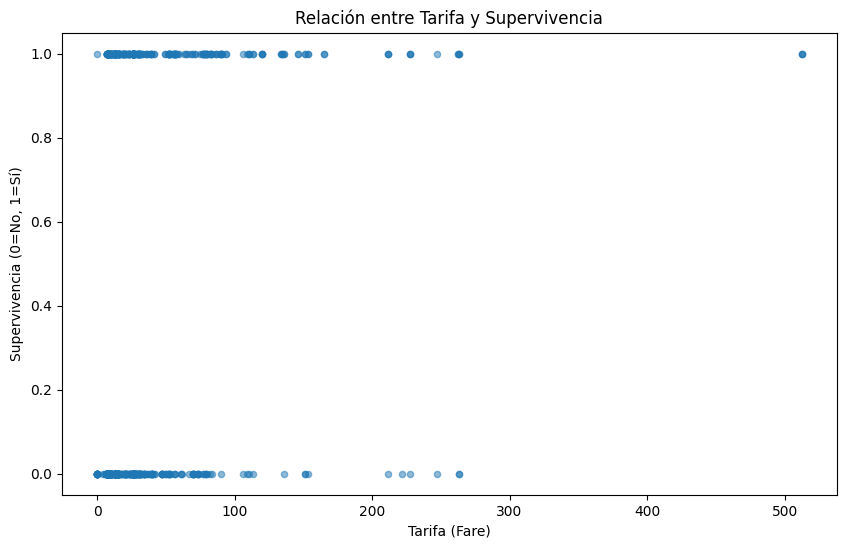

/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/2945758183.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  supervivencia_por_tarifa = df_model.groupby('grupo_tarifa')['Survived'].mean()


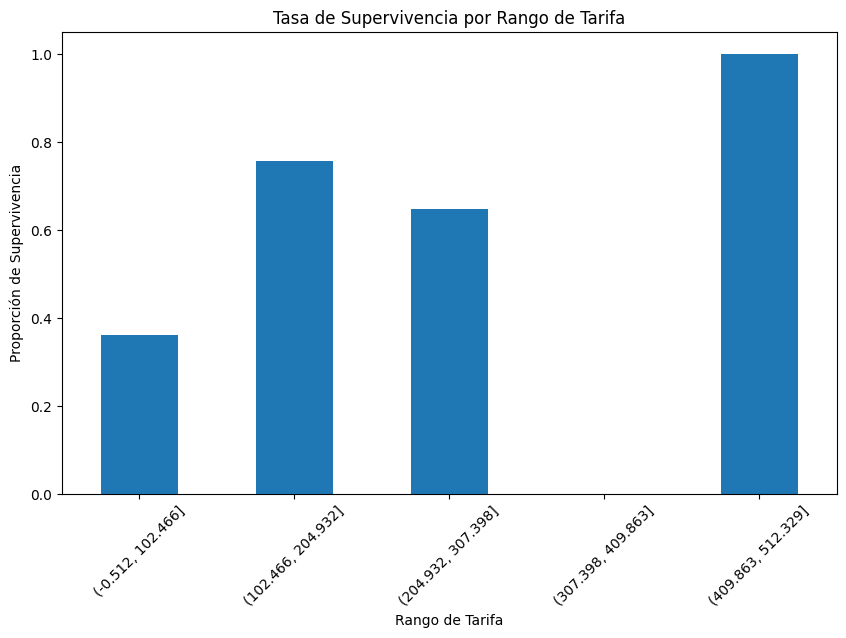

In [29]:
# Crear un gráfico de dispersión para analizar la relación entre Fare y Survived
plt.figure(figsize=(10, 6))
df_model.plot(x='Fare', y='Survived', kind='scatter', alpha=0.5, figsize=(10, 6))
plt.title("Relación entre Tarifa y Supervivencia")
plt.xlabel("Tarifa (Fare)")
plt.ylabel("Supervivencia (0=No, 1=Sí)")
plt.show()

# También calcular la supervivencia promedio por rango de tarifa
df_model['grupo_tarifa'] = pd.cut(df_model['Fare'], bins=5)
supervivencia_por_tarifa = df_model.groupby('grupo_tarifa')['Survived'].mean()
supervivencia_por_tarifa.plot(kind='bar', figsize=(10, 6))
plt.title("Tasa de Supervivencia por Rango de Tarifa")
plt.xlabel("Rango de Tarifa")
plt.ylabel("Proporción de Supervivencia")
plt.xticks(rotation=45)
plt.show()

In [30]:
print(df_model.groupby("Sex")["Survived"].mean())
print(df_model.groupby("Pclass")["Survived"].mean())
print(df_model.groupby(["Sex", "Pclass"])["Survived"].mean())
print(df_model.groupby("Pclass")["Fare"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


## Interpretación de hallazgos

- El sexo muestra una relación muy fuerte con la supervivencia: las mujeres presentan una tasa considerablemente mayor que los hombres.
- La clase también influye de forma importante: la supervivencia disminuye desde primera hasta tercera clase.
- Al combinar sexo y clase, se observa que el sexo parece ser el factor más determinante, aunque la clase introduce diferencias adicionales dentro de cada grupo.
- La tarifa promedio es mucho más alta en primera clase, lo que sugiere que la relación entre `Fare` y supervivencia podría estar mediada por la clase del pasajero.

In [31]:
df_model["grupo_edad"] = pd.cut(
    df_model["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Niño", "Adolescente", "Joven Adulto", "Adulto", "Adulto Mayor"]
)

print(df_model[["Age", "grupo_edad"]].head(10))

    Age    grupo_edad
0  22.0  Joven Adulto
1  38.0        Adulto
2  26.0  Joven Adulto
3  35.0  Joven Adulto
4  35.0  Joven Adulto
5  28.0  Joven Adulto
6  54.0        Adulto
7   2.0          Niño
8  27.0  Joven Adulto
9  14.0   Adolescente


In [32]:
print("Supervivencia por grupo etario:")
print(df_model.groupby("grupo_edad")["Survived"].mean())

Supervivencia por grupo etario:
grupo_edad
Niño            0.579710
Adolescente     0.428571
Joven Adulto    0.353271
Adulto          0.400000
Adulto Mayor    0.227273
Name: Survived, dtype: float64


/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/4144352377.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby("grupo_edad")["Survived"].mean())


In [33]:
df_model["tamano_familia"] = df_model["SibSp"] + df_model["Parch"] + 1

print(df_model[["SibSp", "Parch", "tamano_familia"]].head(10))

   SibSp  Parch  tamano_familia
0      1      0               2
1      1      0               2
2      0      0               1
3      1      0               2
4      0      0               1
5      0      0               1
6      0      0               1
7      3      1               5
8      0      2               3
9      1      0               2


In [34]:
print("Supervivencia por tamaño de familia:")
print(df_model.groupby("tamano_familia")["Survived"].mean().sort_index())

Supervivencia por tamaño de familia:
tamano_familia
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [35]:
df_model.sort_values("Fare", ascending=False)[["Name", "Pclass", "Sex", "Fare", "Survived"]].head(10)

,Name,Pclass,Sex,Fare,Survived
258,"Ward, Miss. Anna",1,female,512.3292,1
737,"Lesurer, Mr. Gustave J",1,male,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,male,512.3292,1
88,"Fortune, Miss. Mabel Helen",1,female,263.0000,1
27,"Fortune, Mr. Charles Alexander",1,male,263.0000,0
341,"Fortune, Miss. Alice Elizabeth",1,female,263.0000,1
438,"Fortune, Mr. Mark",1,male,263.0000,0
311,"Ryerson, Miss. Emily Borie",1,female,262.3750,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,female,262.3750,1
118,"Baxter, Mr. Quigg Edmond",1,male,247.5208,0


/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/3734186080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby("grupo_edad")["Survived"].mean().plot(kind="bar", figsize=(8,5))


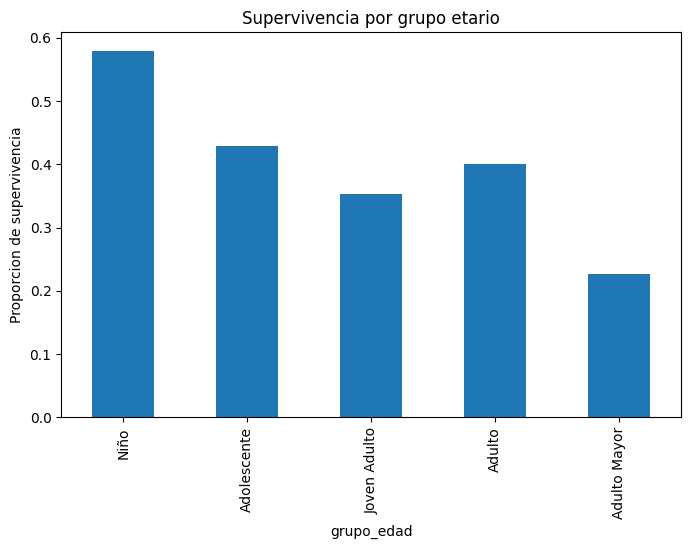

In [36]:
df_model.groupby("grupo_edad")["Survived"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Supervivencia por grupo etario")
plt.ylabel("Proporcion de supervivencia")
plt.show()

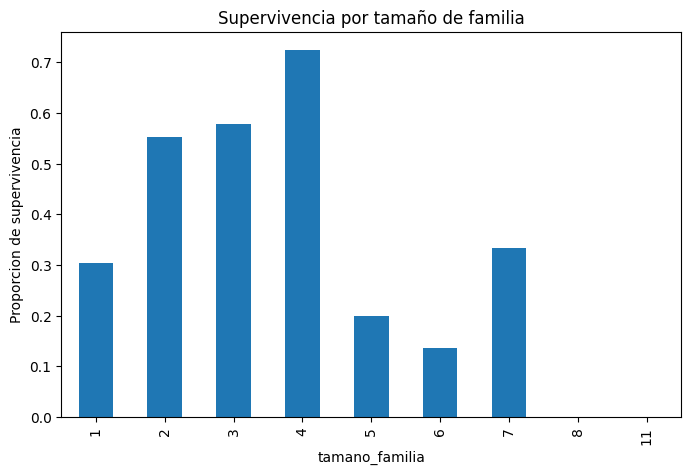

In [37]:
df_model.groupby("tamano_familia")["Survived"].mean().plot(kind="bar", figsize=(8,5))
plt.title("Supervivencia por tamaño de familia")
plt.ylabel("Proporcion de supervivencia")
plt.show()

In [38]:
print(df_model.groupby("grupo_edad")["Survived"].mean())
print(df_model.groupby("tamano_familia")["Survived"].mean().sort_index())

grupo_edad
Niño            0.579710
Adolescente     0.428571
Joven Adulto    0.353271
Adulto          0.400000
Adulto Mayor    0.227273
Name: Survived, dtype: float64
tamano_familia
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


/var/folders/0r/0msggypx26ngb73z3h9vwmhh0000gn/T/ipykernel_74701/3511381667.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby("grupo_edad")["Survived"].mean())


## Hallazgos adicionales

- Los niños presentan la mayor tasa de supervivencia entre los grupos etarios analizados.
- Los adultos mayores muestran la menor probabilidad de supervivencia.
- El tamaño de la familia parece influir, pero no de forma lineal.
- Los pasajeros que viajaban en grupos pequeños o medianos muestran mejores tasas de supervivencia que quienes viajaban solos o en familias muy grandes.
- Estos resultados sugieren que edad, estructura familiar, sexo y clase son variables relevantes para explicar la supervivencia.

## Conclusión general del Día 2

A través de filtros, agrupaciones, ordenamientos y variables derivadas, se identificó que la supervivencia en el Titanic estuvo fuertemente asociada al sexo, la clase, la edad y el tamaño del grupo familiar. Las mujeres, los niños y los pasajeros de clases superiores presentaron mejores tasas de supervivencia. Además, los grupos familiares pequeños y medianos mostraron mejores resultados que quienes viajaban solos o en familias muy grandes.